# Final Project Phase 3 Summary
This Jupyter Notebook (.ipynb) will serve as the skeleton file for your submission for Phase 3 of the Final Project. Complete all sections below as specified in the instructions for the project, covering all necessary details. We will use this to grade your individual code (Do this whether you are in a group or not). Good luck! <br><br>

Note: To edit a Markdown cell, double-click on its text.

## Jupyter Notebook Quick Tips
Here are some quick formatting tips to get you started with Jupyter Notebooks. This is by no means exhaustive, and there are plenty of articles to highlight other things that can be done. We recommend using HTML syntax for Markdown but there is also Markdown syntax that is more streamlined and might be preferable. 
<a href = "https://towardsdatascience.com/markdown-cells-jupyter-notebook-d3bea8416671">Here's an article</a> that goes into more detail. (Double-click on cell to see syntax)

# Heading 1
## Heading 2
### Heading 3
#### Heading 4
<br>
<b>BoldText</b> or <i>ItalicText</i>
<br> <br>
Math Formulas: $x^2 + y^2 = 1$
<br> <br>
Line Breaks are done using br enclosed in < >.
<br><br>
Hyperlinks are done with: <a> https://www.google.com </a> or 
<a href="http://www.google.com">Google</a><br>

# Video Presentation

If you uploaded your Video Presentation to Bluejeans, YouTube, or any other streaming services, please provide the link here:


*   https://youtu.be/E3se3lQlEdA


Make sure the video sharing permissions are accessible for anyone with the provided link.

# Data Collection and Cleaning


Transfer/update the data collection and cleaning you created for Phase II below. You may include additional cleaning functions if you have extra datasets. If no changes are necessary, simply copy and paste your phase II parsing/cleaning functions.


## Downloaded Dataset Requirement



In [ ]:
import pandas as pd
def data_parser():
   df = pd.read_excel("national_owner_M2023_dl.xlsx", sheet_name="National_owner_M2023_dl")
   for col in ["ANNUAL", "HOURLY"]:
       df[col] = df[col].apply(lambda x: "FALSE" if pd.isna(x) or str(x).strip() == "" else x)
   df = df.drop(columns=["JOBS_1000", "LOC_QUOTIENT", "PCT_TOTAL", "PCT_RPT"], errors="ignore")
   df.to_excel("national_owner_M2023_dl_fixed.xlsx", index=False)
   print("Cleaned file saved as national_owner_M2023_dl_fixed.xlsx")
data_parser()

## Web Collection Requirement \#1


In [ ]:
import requests
from bs4 import BeautifulSoup
 
def web_parser1(url, output_file="output.html"):
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    tables = soup.find_all("table")
    html = "<html><head><meta charset='utf-8'></head><body>"
    for i, table in enumerate(tables):
        html += str(table) + "<br><br>"
    html += "</body></html>"
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(html)
    print("Done")
 
web_parser1("https://www.bls.gov/oes/2023/may/oes172112.htm")

## Web Collection Requirement #2

In [ ]:
import requests, pandas as pd, json

USER_ID = "TgXba8ZcAwMuMBd"
API_TOKEN = "V7QtHINZ+2/9w8smA9rX5WSVYZi876r4eV6DNFfaz/fh8gI/nH+BO1Cm+YcpBYzMPpiTVIzJrNYc4TKwuTxEWA=="
INPUT_CSV = "top5chatg_zipcodes_per_state.csv"
OUTPUT_JSON = "industrial_engineer_wages_by_zip_deduped.json"
OCC_CODE = "17-2112.00"
BASE_URL = f"https://api.careeronestop.org/v1/comparesalaries/{USER_ID}/wage"

def fetch(zip_code: str):
    r = requests.get(
        BASE_URL,
        headers={"Authorization": f"Bearer {API_TOKEN}", "Accept": "application/json"},
        params={"keyword": OCC_CODE, "location": str(zip_code), "enableMetaData": "true"},
    )
    d = r.json()
    o = d.get("OccupationDetail", {})
    w = o.get("Wages", {}) or {}
    yr, src = w.get("WageYear"), w.get("Source")
    rows, nums = [], ["Pct10", "Pct25", "Median", "Pct75", "Pct90"]
    for level, lst in (("National", w.get("NationalWagesList") or []),
                       ("State",    w.get("StateWagesList")    or []),
                       ("Area",     w.get("BLSAreaWagesList")  or [])):
        for rec in lst:
            row = {
                "requested_zip": str(zip_code),
                "area_name": rec.get("AreaName"),
                "area_type": rec.get("AreaType"),
                "level": level,
                "rate_type": rec.get("RateType"),
                "pct10": rec.get("Pct10"),
                "pct25": rec.get("Pct25"),
                "median": rec.get("Median"),
                "pct75": rec.get("Pct75"),
                "pct90": rec.get("Pct90"),
                "wage_year": yr,
                "source": src,
                "occupation_title": o.get("OccupationTitle"),
                "occupation_code": o.get("OccupationCode"),
            }
            for k in ("pct10","pct25","median","pct75","pct90"):
                v = row.get(k)
                row[k] = float(v) if v is not None else None
            if (row.get("rate_type") or "").lower() == "hourly":
                for k in ["pct10", "pct25", "median", "pct75", "pct90"]:
                    if row[k] is not None:
                        row[k] = round(row[k], 2)
            rows.append(row)
    return rows

def main():
    zips = (
        pd.read_csv(INPUT_CSV)["zip_code"].astype(str).str.zfill(5).unique().tolist()
    )
    all_rows = [r for z in zips for r in fetch(z)]
    seen, out = set(), []
    for r in all_rows:
        fp = (
            r.get("area_name"),
            r.get("level"),
            r.get("rate_type"),
            r.get("pct10"),
            r.get("pct25"),
            r.get("median"),
            r.get("pct75"),
            r.get("pct90"),
            r.get("wage_year"),
            r.get("occupation_code"),
        )
        if fp not in seen:
            seen.add(fp)
            out.append(r)
    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(out, f, indent=2)

if __name__ == "__main__":
    main()

#Inconsistency Revisions
 **If you were requested to revise your inconsistency section from Phase II, enter your responses here. Otherwise, ignore this section.**

For each inconsistency (NaN, null, duplicate values, empty strings, etc.) you discover in your datasets, write at least 2 sentences stating the significance, how you identified it, and how you handled it.

1. 

2. 

3. 

4. (if applicable)

5. (if applicable)


## Data Sources

Include sources (as links) to your datasets. If any of these are different from your sources used in Phase II, please <b>clearly</b> specify.

*   Downloaded Dataset Source:  https://www.bls.gov/oes/2023/may/naics4_611300.htm#00-0000 (DOWNLOADED DATASET)
*   Web Collection #1 Source:  https://www.bls.gov/oes/2023/may/oes172112.htm (HTML WEB PAGE)
*   Web Collection #2 Source:  https://www.careeronestop.org/Developers/WebAPI/Salaries/get-salary-details.aspx (WEB API)



# Data Analysis
For the Data Analysis section, you are required to utilize your data to complete the following:

*   Create at least 5 insights
*   Generate at least 3 data visualizations

Create a function for each of the following sections mentioned above. Do not forget to fill out the explanation section for each function. 

Make sure your data analysis is not too simple. Performing complex aggregation and using modules not taught in class shows effort, which will increase the chance of receiving full credit. 

# Topic Summary

Please provide a brief executive summary (5 sentences or less) discussing your topic: 
Our topic is about Industrial Engineering employment and salary in various sectors and locations of the US. We were able to get wage information for a lot of different sectors and industries in the US for a variety of occupation through downloaded datasets and websites from the Bureau of Labor Statistics. We were also able to get wage information by specific zip codes for certain occupations which helped us add another layer to our findings. The purpose of our project is to try to inform Industrial Engineers on what locations and industries are most favorable for them.

## Insights

In [11]:
import pandas as pd

df = pd.read_excel("nat4d_M2023_dl_fixed.xlsx")
ie = df[df["OCC_TITLE"] == "Industrial Engineers"].copy()
ie["A_MEAN"] = pd.to_numeric(ie["A_MEAN"], errors="coerce")
ie = ie.dropna(subset=["A_MEAN"])
ie_ind = (
    ie.groupby(["NAICS", "NAICS_TITLE"], as_index=False)["A_MEAN"]
      .mean()
)
highest = ie_ind.loc[ie_ind["A_MEAN"].idxmax()]
lowest  = ie_ind.loc[ie_ind["A_MEAN"].idxmin()]
print("Highest paying industry for Industrial Engineers:")
print(highest.to_string(index=False))
print("\nLowest paying industry for Industrial Engineers:")
print(lowest.to_string(index=False))

Highest paying industry for Industrial Engineers:
                                            519200
Web Search Portals, Libraries, Archives, and Ot...
                                          191600.0

Lowest paying industry for Industrial Engineers:
                                    516100
Radio and Television Broadcasting Stations
                                   61620.0


### Insight 1 Explanation

This insight is able to tell us what industries pay Industrial Engineers the highest and lowest salaries on average. (The number with no decimals is the NAICS number associated with the sector)

In [12]:
import pandas as pd

df = pd.read_excel("nat4d_M2023_dl_fixed.xlsx")
ie = df[df["OCC_TITLE"] == "Industrial Engineers"].copy()
ie["TOT_EMP"] = pd.to_numeric(ie["TOT_EMP"], errors="coerce")
ie = ie.dropna(subset=["TOT_EMP"])
sector_emp = (
    ie.groupby(["NAICS", "NAICS_TITLE"], as_index=False)["TOT_EMP"]
      .sum()
)
highest = sector_emp.loc[sector_emp["TOT_EMP"].idxmax()]
lowest  = sector_emp.loc[sector_emp["TOT_EMP"].idxmin()]
print("Highest employment sector for Industrial Engineers:")
print(highest.to_string(index=False))
print("\nLowest employment sector for Industrial Engineers:")
print(lowest.to_string(index=False))

Highest employment sector for Industrial Engineers:
                                          541300
Architectural, Engineering, and Related Services
                                         23280.0

Lowest employment sector for Industrial Engineers:
                316200
Footwear Manufacturing
                  30.0


### Insight 2 Explanation

This insight is able to tell us what industries employ the most and the least Industrial Engineers. (The number with no decimals is the NAICS number associated with the sector)

In [13]:
import pandas as pd
def visual3():
    df = pd.read_json("industrial_engineer_wages_by_zip_deduped.json")
    annual = df[df["rate_type"] == "Annual"].copy()
    state_rows = annual[annual["level"] == "State"].copy()
    state_abbrev = {
        "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
        "Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
        "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
        "Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD","Massachusetts":"MA",
        "Michigan":"MI","Minnesota":"MN","Mississippi":"MS","Missouri":"MO","Montana":"MT",
        "Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM",
        "New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
        "Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
        "South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
        "Virginia":"VA","Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
    }
    state_rows["state"] = state_rows["area_name"].map(state_abbrev)
    state_rows = state_rows.dropna(subset=["state"])
    state_rows["median"] = pd.to_numeric(state_rows["median"], errors="coerce")
    state_rows = state_rows.dropna(subset=["median"])
    state_wages = (
        state_rows.groupby(["state", "area_name"], as_index=False)["median"]
        .median()
    )
    highest = state_wages.loc[state_wages["median"].idxmax()]
    lowest  = state_wages.loc[state_wages["median"].idxmin()]
    print("Highest paying state for Industrial Engineers:")
    print(f"{highest['area_name']} ({highest['state']}): {highest['median']:.0f}")
    print("\nLowest paying state for Industrial Engineers:")
    print(f"{lowest['area_name']} ({lowest['state']}): {lowest['median']:.0f}")
visual3()

Highest paying state for Industrial Engineers:
Alaska (AK): 142980

Lowest paying state for Industrial Engineers:
North Dakota (ND): 84610


### Insight 3 Explanation

This insight is able to tell us what states pay Industrial engineers the most as well as the least

R² Score: 0.019


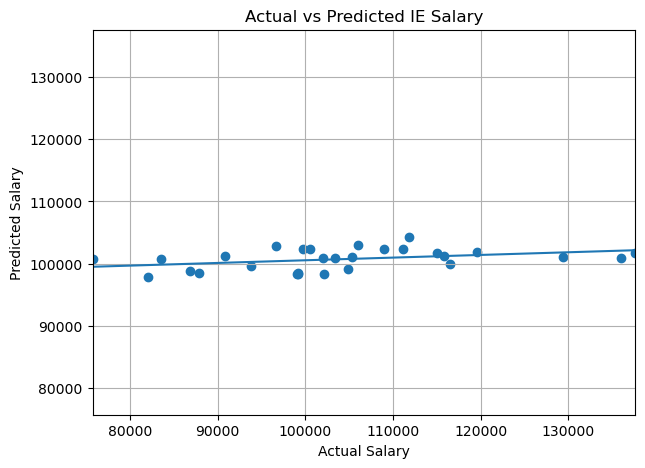

LinearRegression()

In [14]:
def visual4():
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score
    import matplotlib.pyplot as plt
 
    df = pd.read_excel("nat4d_M2023_dl.xlsx")
 
    df = df[df["OCC_CODE"] == "17-2112"].copy() 
 
    for col in ["TOT_EMP", "A_MEAN"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
 
    df = df.dropna(subset=["NAICS", "OWN_CODE", "TOT_EMP", "A_MEAN"])
 
    df["NAICS_CODE"] = pd.factorize(df["NAICS"])[0]
    df["OWNERSHIP_CODE"] = pd.factorize(df["OWN_CODE"])[0]
 
    X = df[["NAICS_CODE", "OWNERSHIP_CODE", "TOT_EMP"]] 
 
    y = df["A_MEAN"] 
 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
 
    model = LinearRegression()
    model.fit(X_train, y_train)
 
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
 
    print("R² Score:", round(score, 3))
 
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred)
 
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
 
    x_vals = y_test.values
    y_vals = y_pred
    m, b = np.polyfit(x_vals, y_vals, 1)          
    x_line = np.linspace(min_val, max_val, 100)
    y_line = m * x_line + b
    plt.plot(x_line, y_line, label="Line of best fit")
 
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.title("Actual vs Predicted IE Salary")
    plt.grid(True)
    plt.show()
 
    return model
 
 
visual4()

### Insight 4 Explanation

This insight is trying to predict if there is a correlation between IE salary, NAICS sector, ownership type, and employment size through linear regression

Test accuracy: 0.862
[[25  0]
 [ 4  0]]


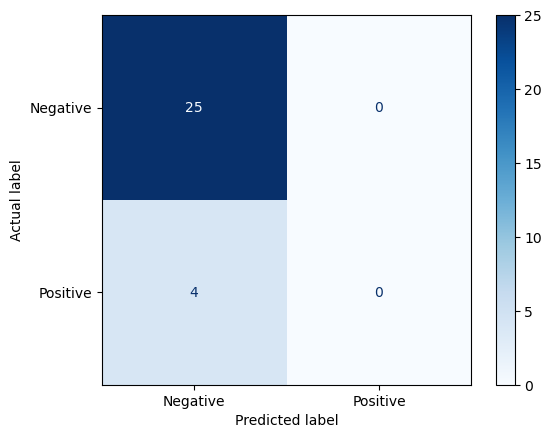

In [23]:
def visual5():
  import pandas as pd
 
  from sklearn.model_selection import train_test_split
  from sklearn.pipeline import Pipeline
  from sklearn.linear_model import LogisticRegression
  from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
  import matplotlib.pyplot as plt
 
  df = pd.read_excel("nat4d_M2023_dl.xlsx")
 
  df["NAICS_str"] = df["NAICS"].astype(str)
  df["NAICS4"] = df["NAICS_str"].str[:4]
 
  df["A_MEAN_num"] = pd.to_numeric(df["A_MEAN"], errors="coerce")
  df["TOT_EMP_num"] = pd.to_numeric(
      df["TOT_EMP"].replace({"*": None, "**": None}), errors="coerce"
  )
 
  p90 = df.groupby("NAICS4")["A_MEAN_num"].quantile(0.9)
  df["p90_A_MEAN"] = df["NAICS4"].apply(lambda x: p90[x]) 
 
  ie = df[df["OCC_TITLE"] == "Industrial Engineers"].copy()
 
  ie = ie.dropna(subset=["A_MEAN_num", "TOT_EMP_num", "p90_A_MEAN"]).copy()
 
  ie["is_top10"] = (ie["A_MEAN_num"] >= ie["p90_A_MEAN"]).astype(int) 
 
  feature_df = ie[["NAICS4", "TOT_EMP_num"]].copy() 
 
  X = pd.get_dummies(feature_df, columns=["NAICS4"], drop_first=True) 
 
  y = ie["is_top10"] 
 
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = LogisticRegression()
  model.fit(X_train, y_train)
  accuracy = model.score(X_test, y_test)
  print("Test accuracy:", round(accuracy, 3))
 
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  print(cm)
  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=["Negative", "Positive"]
  )
  fig, ax = plt.subplots()
  disp.plot(cmap="Blues", ax=ax)
  plt.xlabel("Predicted label")
  plt.ylabel("Actual label")
  plt.show()
 
visual5()

### Insight 5 Explanation

This insight is trying to predict whether there is a correlation between NAICS sectors and employment size with Industrial Engineers being in the top 10% of pay within their respective industries through logistic regression

## Data Visualizations

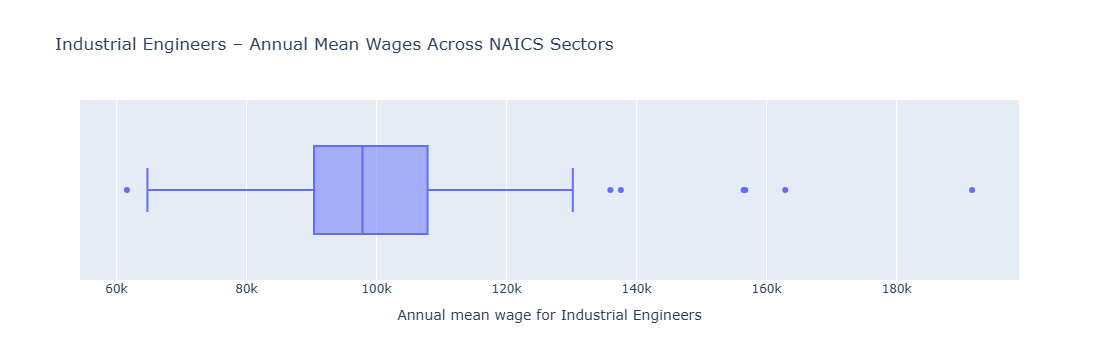

In [24]:
import pandas as pd
import plotly.express as px
df = pd.read_excel("nat4d_M2023_dl_fixed.xlsx")
ie = df[df["OCC_TITLE"] == "Industrial Engineers"].copy()
ie["A_MEAN"] = pd.to_numeric(ie["A_MEAN"], errors="coerce")
ie = ie.dropna(subset=["A_MEAN"])
fig = px.box(
    ie,
    x="A_MEAN",                 
    points="outliers",           
    hover_data=["NAICS", "NAICS_TITLE"],
    labels={"A_MEAN": "Annual mean wage for Industrial Engineers"},
    title="Industrial Engineers – Annual Mean Wages Across NAICS Sectors"
)

fig.show()


### Visualization 1 Explanation

This is a box plot that shows Industrial Engineering average annual salary across all sectors, the only points that are plotted are the outliers since that is the most significant information

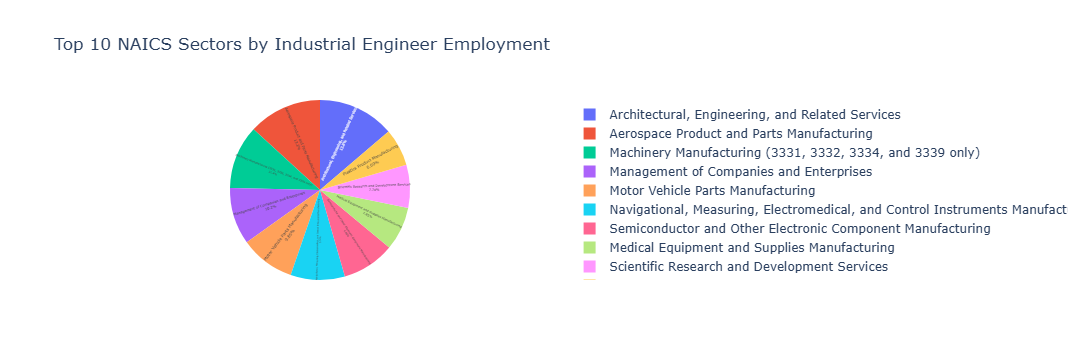

In [25]:
import pandas as pd
import plotly.express as px

df = pd.read_excel("nat4d_M2023_dl_fixed.xlsx")
ie = df[df["OCC_TITLE"] == "Industrial Engineers"].copy()
ie["TOT_EMP"] = pd.to_numeric(ie["TOT_EMP"], errors="coerce")
ie = ie.dropna(subset=["TOT_EMP"])
sector_emp = (
    ie.groupby(["NAICS", "NAICS_TITLE"], as_index=False)["TOT_EMP"]
      .sum()
      .sort_values("TOT_EMP", ascending=False)
      .head(10)
)
fig = px.pie(
    sector_emp,
    values="TOT_EMP",
    names="NAICS_TITLE",
    hover_data=["NAICS", "TOT_EMP"],
    title="Top 10 NAICS Sectors by Industrial Engineer Employment"
)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()

### Visualization 2 Explanation

This is a piechart displaying the top 10 industries that employ the most industrial engineers

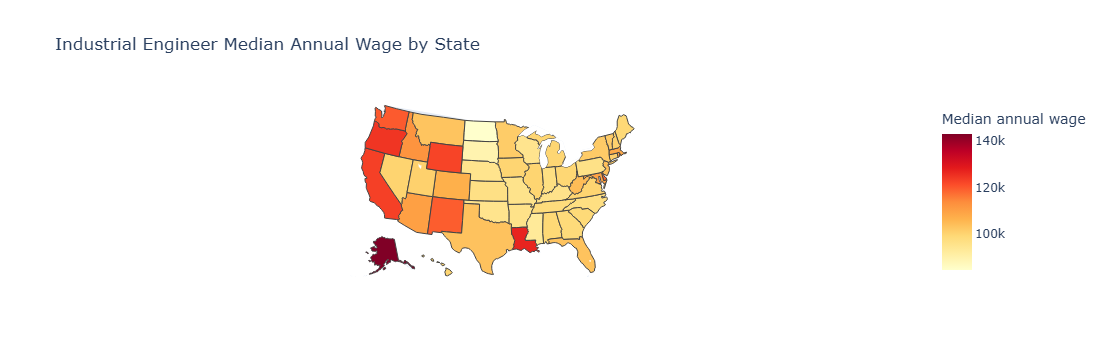

In [26]:
import pandas as pd
import plotly.express as px

def visual3():
    df = pd.read_json("industrial_engineer_wages_by_zip_deduped.json")
    annual = df[df["rate_type"] == "Annual"].copy()
    state_rows = annual[annual["level"] == "State"].copy()
    state_abbrev = {
        "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
        "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
        "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
        "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
        "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
        "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
        "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
        "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
        "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
        "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
        "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN",
        "Texas": "TX", "Utah": "UT", "Vermont": "VT", "Virginia": "VA",
        "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
    }
    state_rows["state"] = state_rows["area_name"].map(state_abbrev)
    state_rows = state_rows.dropna(subset=["state"])
    fig = px.choropleth(
        state_rows,
        locations="state",                 
        locationmode="USA-states",         
        color="median",                    
        scope="usa",
        color_continuous_scale="YlOrRd",   
        labels={"median": "Median annual wage"},
        title="Industrial Engineer Median Annual Wage by State"
    )
    
    fig.show()

visual3()

### Visualization 3 Explanation

This is a choropleth map that shows varying degrees of colors, yellow through red, depending on the average Industrial Engineering pay per state

# Cited Sources

If you used any additional sources to complete your Data Analysis section, list them here:


*   Example Module Documentation
*   Example Stack Overflow Assistance



# Graphical User Interface (GUI) Implementation
If you decide to create a GUI for Phase II, please create a separate Python file (.py) to build your GUI. You must submit both the completed PhaseII.ipynb and your Python GUI file.

# Submission

Prior to submitting your notebook to Gradescope, be sure to <b>run all functions within this file</b>. We will not run your functions ourselves, so we must see your outputs within this file in order to receive full credit.
